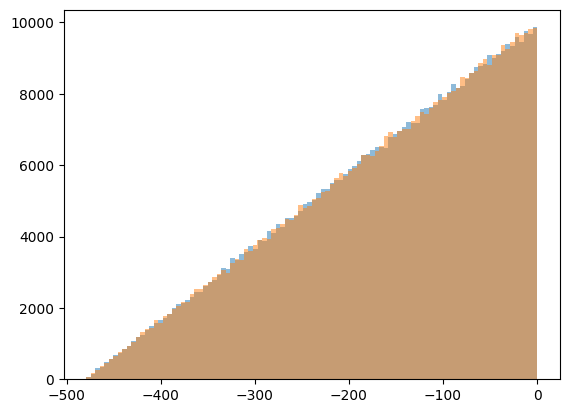

In [1]:
import bilby
import matplotlib.pyplot as plt

number = 1000000

# priors = {}
priors = bilby.core.prior.PriorDict()
priors['f1'] = bilby.core.prior.Uniform(20, 500, name='f1')
priors['f2'] = bilby.core.prior.Uniform(20, 500, name='f2')
f1_sample = priors['f1'].sample(number)
f2_sample = priors['f2'].sample(number)
deltaf_sample = f2_sample - f1_sample
f_mask = deltaf_sample < 0

priors['analytical'] = bilby.core.prior.analytical.Triangular(0, -480, 0, r"$\Delta f$ [Hz]")
analytical_samples = priors['analytical'].sample(len(deltaf_sample[f_mask]))

# def condition_func(reference_params, f1):
#     return dict(minimum=reference_params['minimum'], maximum=f1)

# priors['f2_conditional'] = bilby.core.prior.conditional.ConditionalUniform(condition_func=condition_func, name='f2_conditional', latex_label='$f_2$ [Hz]', minimum=20, maximum=500)
# samples = priors.sample(size=number)
# f2_conditional_samples = samples['f2_conditional']
# f2_conditional_samples = priors['f2_conditional'].sample(['f1'])

plt.hist(deltaf_sample[f_mask], bins=100, alpha=0.5)
plt.hist(analytical_samples, bins=100, alpha=0.5)
plt.show()

# plt.hist(f1_sample, bins=100)
# plt.hist(f2_sample, bins=100)
# plt.hist(f2_conditional_samples, bins=100, alpha=0.3)
# plt.show()
# print(len(f2_conditional_samples))

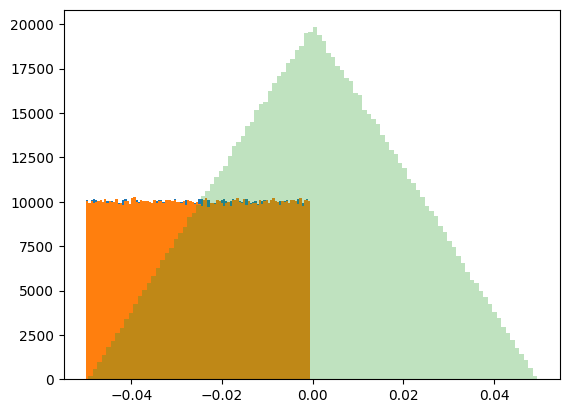

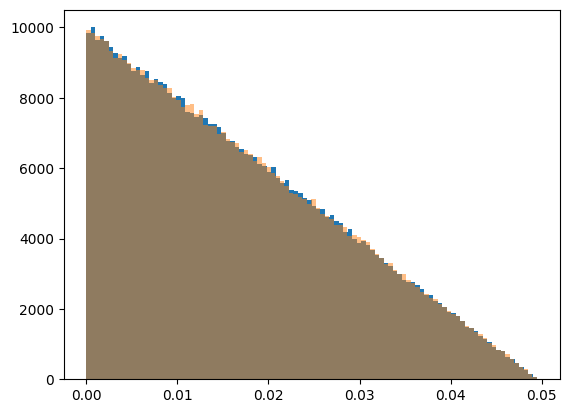

In [2]:
import bilby
import matplotlib.pyplot as plt

number = 1000000

priors = bilby.core.prior.PriorDict()
priors['tau1'] = bilby.core.prior.Uniform(-0.05, -0.0005, r"$\tau_1$ [ms]")
priors['tau2'] = bilby.core.prior.Uniform(-0.05, -0.0005, r"$\tau_2$ [ms]")
tau1_sample = priors['tau1'].sample(number)
tau2_sample = priors['tau2'].sample(number)
deltatau_sample = tau2_sample - tau1_sample
tau_mask = deltatau_sample > 0

priors['analytical'] = bilby.core.prior.analytical.Triangular(0, 0, 0.0495, r"$\Delta \tau$ [Hz]")
analytical_samples = priors['analytical'].sample(len(deltatau_sample[tau_mask]))

plt.hist(tau1_sample, bins=100)
plt.hist(tau2_sample, bins=100)
plt.hist(deltatau_sample, bins=100, alpha=0.3)
plt.show()

plt.hist(deltatau_sample[tau_mask], bins=100)
plt.hist(analytical_samples, bins=100, alpha=0.5)
plt.show()

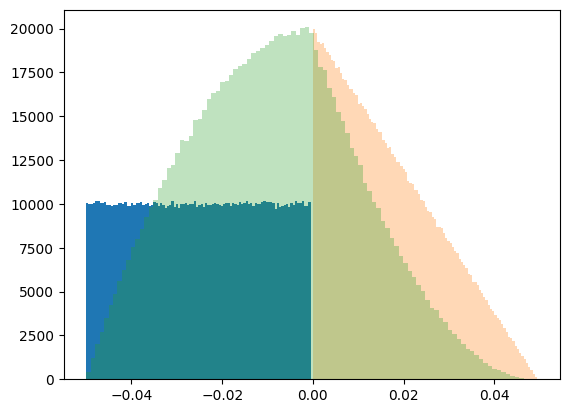

In [3]:
import bilby
import matplotlib.pyplot as plt

number = 1000000

priors = bilby.core.prior.PriorDict()
priors['tau1'] = bilby.core.prior.Uniform(-0.05, -0.0005, r"$\tau_1$ [ms]")
tau1_sample = priors['tau1'].sample(number)

priors['analytical'] = bilby.core.prior.analytical.Triangular(0, 0, 0.0495, r"$\Delta \tau$ [Hz]")
analytical_samples = priors['analytical'].sample(number)

tau2_sample = tau1_sample + analytical_samples

plt.hist(tau1_sample, bins=100)
plt.hist(analytical_samples, bins=100, alpha=0.3)
plt.hist(tau2_sample, bins=100, alpha=0.3)
plt.show()


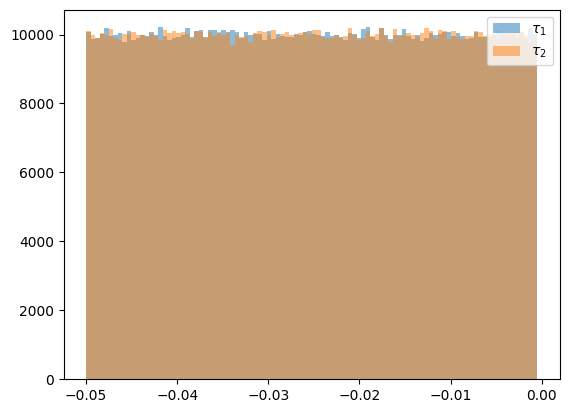

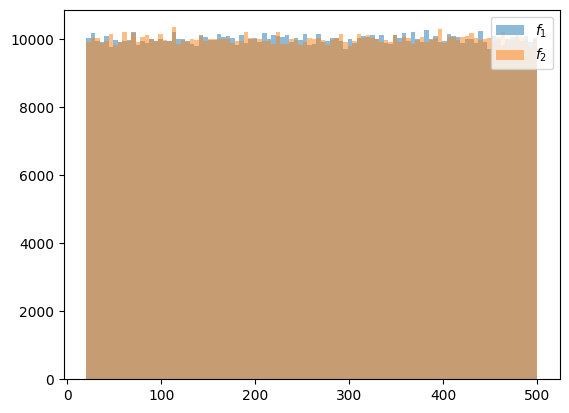

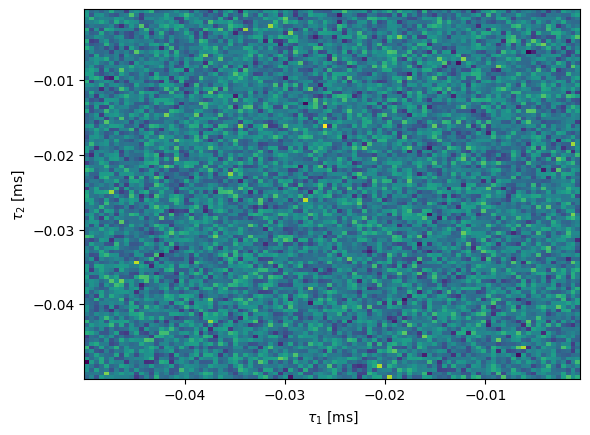

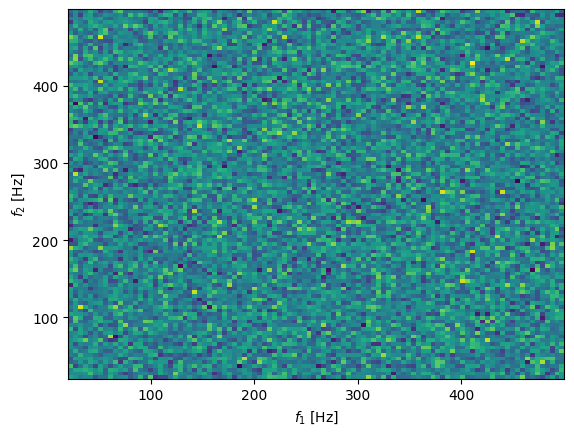

In [6]:
import bilby
import matplotlib.pyplot as plt

tau1_prior = bilby.core.prior.Uniform(-0.05, -0.0005, r"$\tau_1$ [ms]")
tau2_prior = bilby.core.prior.Uniform(-0.05, -0.0005, r"$\tau_2$ [ms]")

f1_prior = bilby.core.prior.Uniform(20, 500, r"$f_1$ [Hz]")
f2_prior = bilby.core.prior.Uniform(20, 500, r"$f_2$ [Hz]")

number = 1000000
tau1_sample = tau1_prior.sample(number)
tau2_sample = tau2_prior.sample(number)
f1_sample = f1_prior.sample(number)
f2_sample = f2_prior.sample(number)

plt.hist(tau1_sample, bins=100, alpha=0.5, label=r'$\tau_1$')
plt.hist(tau2_sample, bins=100, alpha=0.5, label=r'$\tau_2$')
plt.legend()
plt.show()

plt.hist(f1_sample, bins=100, alpha=0.5, label=r'$f_1$')
plt.hist(f2_sample, bins=100, alpha=0.5, label=r'$f_2$')
plt.legend()
plt.show()

plt.hist2d(tau1_sample, tau2_sample, bins=100)
plt.xlabel(r'$\tau_1$ [ms]')
plt.ylabel(r'$\tau_2$ [ms]')
plt.show()

plt.hist2d(f1_sample, f2_sample, bins=100)
plt.xlabel(r'$f_1$ [Hz]')
plt.ylabel(r'$f_2$ [Hz]')
plt.show()


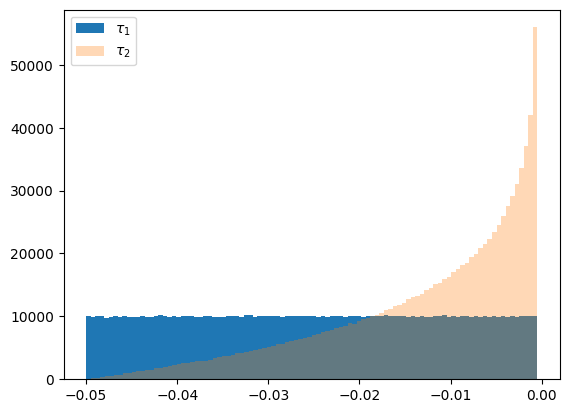

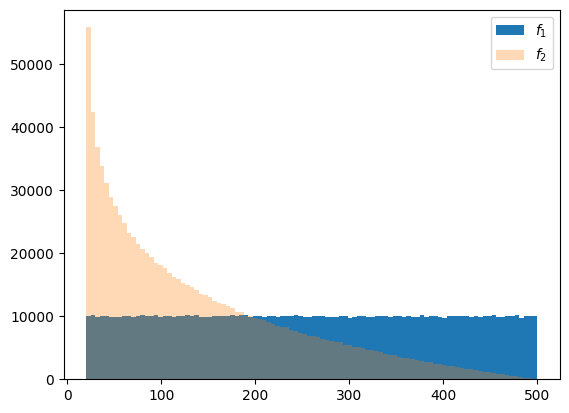

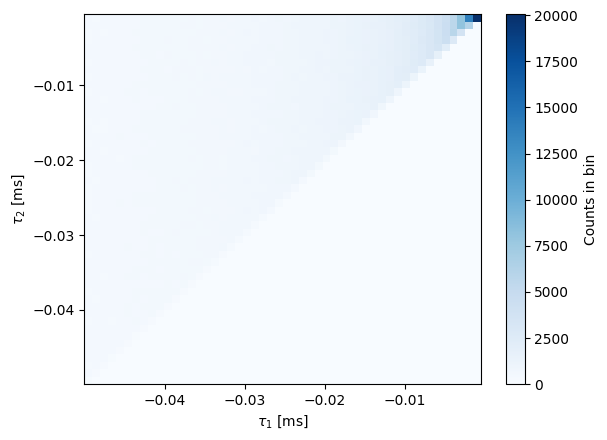

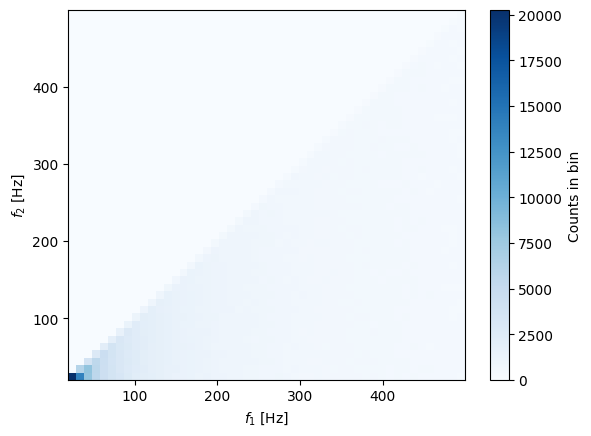

In [4]:
import bilby
import matplotlib.pyplot as plt

def condition_for_f2(reference_params, f1):
        return dict(minimum=20, maximum=f1)

def condition_for_tau2(reference_params, tau1):
    return dict(minimum=tau1, maximum=-0.0005)

N = 1000000

tau1_prior = bilby.core.prior.Uniform(minimum=-0.05, maximum=-0.0005, name='tau1', latex_label=r"$\tau_1$ [ms]")
tau2_conditional_prior = bilby.core.prior.conditional.ConditionalUniform(condition_func=condition_for_tau2, name='tau2', latex_label='$\\tau_2$ [ms]', minimum=-0.05, maximum=-0.0005)

f1_prior = bilby.core.prior.Uniform(minimum=20, maximum=500, name='f1', latex_label=r"$f_1$ [Hz]")
f2_conditional_prior = bilby.core.prior.conditional.ConditionalUniform(condition_func=condition_for_f2, name='f2', latex_label='$\\tau_2$ [ms]', minimum=20, maximum=500)

tau1_samples = tau1_prior.sample(N)
tau2_conditional_samples = tau2_conditional_prior.sample(size=N, tau1=tau1_samples)
deltatau_samples = tau2_conditional_samples - tau1_samples

f1_samples = f1_prior.sample(N)
f2_conditional_samples = f2_conditional_prior.sample(size=N, f1=f1_samples)
deltaf_samples = f2_conditional_samples - f1_samples

plt.hist(tau1_samples, bins=100, label=r'$\tau_1$')
plt.hist(tau2_conditional_samples, bins=100, alpha=0.3, label=r'$\tau_2$')
# plt.hist(deltatau_samples, bins=100, alpha=0.3, label=r'$\Delta \tau$')
plt.legend()
plt.show()

plt.hist(f1_samples, bins=100, label=r'$f_1$')
plt.hist(f2_conditional_samples, bins=100, alpha=0.3, label=r'$f_2$')
plt.legend()
plt.show()

plt.hist2d(tau1_samples, tau2_conditional_samples, bins=50, cmap="Blues")
plt.colorbar(label="Counts in bin")
plt.xlabel(r"$\tau_1$ [ms]")
plt.ylabel(r"$\tau_2$ [ms]")
plt.show()


plt.hist2d(f1_samples, f2_conditional_samples, bins=50, cmap="Blues")
plt.colorbar(label="Counts in bin")
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.show()

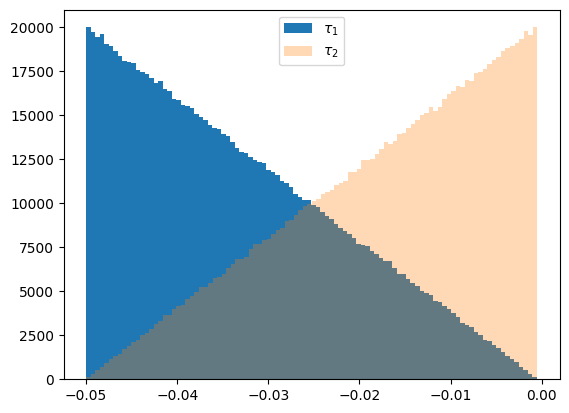

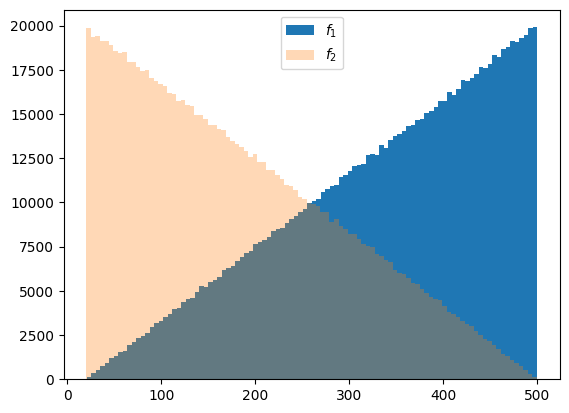

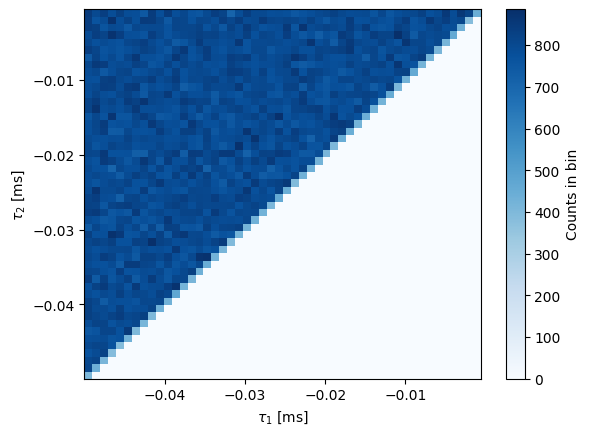

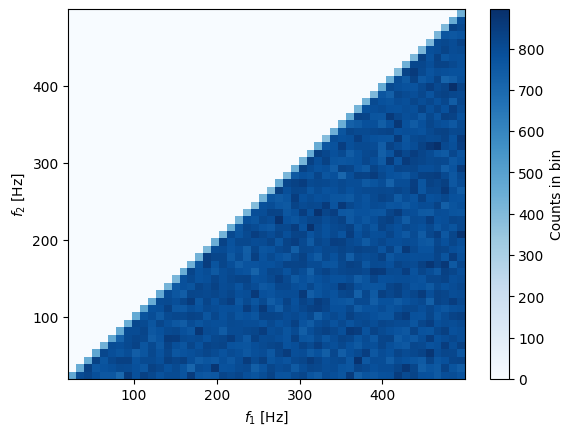

In [5]:
import bilby
import matplotlib.pyplot as plt
import numpy as np

def condition_for_f2(reference_params, f1):
        return dict(minimum=20, maximum=f1)

def condition_for_tau2(reference_params, tau1):
    return dict(minimum=tau1, maximum=-0.0005)

N = 1000000

tau1_prior = bilby.core.prior.Triangular(mode=-0.05, minimum=-0.05, maximum=-0.0005, name='tau1', latex_label=r"$\tau_1$ [ms]")
tau2_conditional_prior = bilby.core.prior.conditional.ConditionalUniform(condition_func=condition_for_tau2, name='tau2', latex_label='$\\tau_2$ [ms]', minimum=-0.05, maximum=-0.0005)

f1_prior = bilby.core.prior.Triangular(mode=500, minimum=20, maximum=500, name='f1', latex_label=r"$f_1$ [Hz]")
f2_conditional_prior = bilby.core.prior.conditional.ConditionalUniform(condition_func=condition_for_f2, name='f2', latex_label='$\\tau_2$ [ms]', minimum=20, maximum=500)

tau1_samples = tau1_prior.sample(N)
tau2_conditional_samples = tau2_conditional_prior.sample(size=N, tau1=tau1_samples)
deltatau_samples = tau2_conditional_samples - tau1_samples

f1_samples = f1_prior.sample(N)
f2_conditional_samples = f2_conditional_prior.sample(size=N, f1=f1_samples)
deltaf_samples = f2_conditional_samples - f1_samples

plt.hist(tau1_samples, bins=100, label=r'$\tau_1$')
plt.hist(tau2_conditional_samples, bins=100, alpha=0.3, label=r'$\tau_2$')
# plt.hist(deltatau_samples, bins=100, alpha=0.3, label=r'$\Delta \tau$')
plt.legend()
plt.show()

plt.hist(f1_samples, bins=100, label=r'$f_1$')
plt.hist(f2_conditional_samples, bins=100, alpha=0.3, label=r'$f_2$')
plt.legend()
plt.show()

plt.hist2d(tau1_samples, tau2_conditional_samples, bins=50, cmap="Blues")
plt.colorbar(label="Counts in bin")
plt.xlabel(r"$\tau_1$ [ms]")
plt.ylabel(r"$\tau_2$ [ms]")
plt.show()

plt.hist2d(f1_samples, f2_conditional_samples, bins=50, cmap="Blues")
plt.colorbar(label="Counts in bin")
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.show()

# $$\tau > 0$$

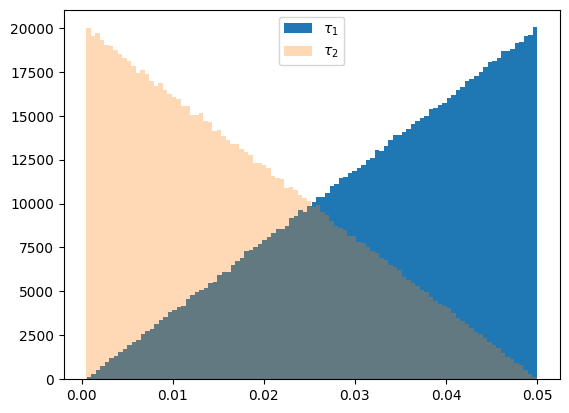

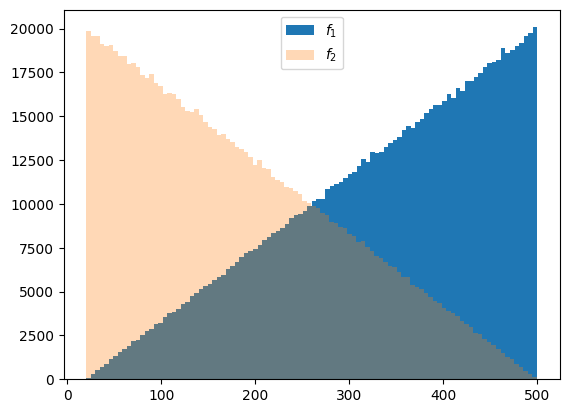

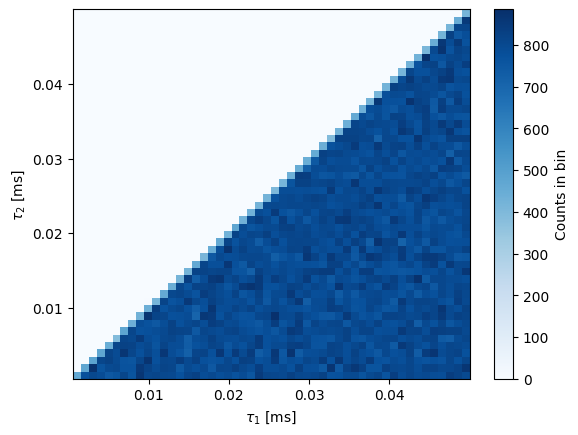

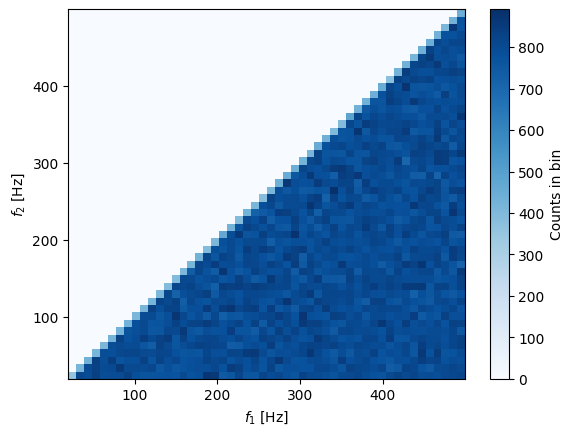

In [1]:
import bilby
import matplotlib.pyplot as plt
import numpy as np

def condition_for_f2(reference_params, f1):
        return dict(minimum=reference_params['minimum'], maximum=f1)

def condition_for_tau2(reference_params, tau1):
    return dict(minimum=reference_params['minimum'], maximum=tau1)

N = 1000000

tau1_prior = bilby.core.prior.Triangular(mode=0.05, minimum=0.0005, maximum=0.05, name='tau1', latex_label=r"$\tau_1$ [ms]")
tau2_conditional_prior = bilby.core.prior.conditional.ConditionalUniform(condition_func=condition_for_tau2, name='tau2', latex_label='$\\tau_2$ [ms]', minimum=0.0005, maximum=0.05)

f1_prior = bilby.core.prior.Triangular(mode=500, minimum=20, maximum=500, name='f1', latex_label=r"$f_1$ [Hz]")
f2_conditional_prior = bilby.core.prior.conditional.ConditionalUniform(condition_func=condition_for_f2, name='f2', latex_label='$\\tau_2$ [ms]', minimum=20, maximum=500)

tau1_samples = tau1_prior.sample(N)
tau2_conditional_samples = tau2_conditional_prior.sample(size=N, tau1=tau1_samples)
deltatau_samples = tau2_conditional_samples - tau1_samples

f1_samples = f1_prior.sample(N)
f2_conditional_samples = f2_conditional_prior.sample(size=N, f1=f1_samples)
deltaf_samples = f2_conditional_samples - f1_samples

plt.hist(tau1_samples, bins=100, label=r'$\tau_1$')
plt.hist(tau2_conditional_samples, bins=100, alpha=0.3, label=r'$\tau_2$')
# plt.hist(deltatau_samples, bins=100, alpha=0.3, label=r'$\Delta \tau$')
plt.legend()
plt.show()

plt.hist(f1_samples, bins=100, label=r'$f_1$')
plt.hist(f2_conditional_samples, bins=100, alpha=0.3, label=r'$f_2$')
plt.legend()
plt.show()

plt.hist2d(tau1_samples, tau2_conditional_samples, bins=50, cmap="Blues")
plt.colorbar(label="Counts in bin")
plt.xlabel(r"$\tau_1$ [ms]")
plt.ylabel(r"$\tau_2$ [ms]")
plt.show()

plt.hist2d(f1_samples, f2_conditional_samples, bins=50, cmap="Blues")
plt.colorbar(label="Counts in bin")
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.show()